# MAC_De-randomization

In [ ]:
import random
random.seed(42)

### Load Data and Combined Lecture Dataset

In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import os

DATA_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_lecture-dataset" / "lecture-dataset"

data_files = list(DATA_PATH.glob("*.csv"))

data_frames = []

for f in tqdm(data_files, desc="Loading CSV files"):
    df = pd.read_csv(f)
    data_frames.append(df)

# Merge all data frames into single
cdf = pd.concat(data_frames, ignore_index=True)

# convert timestamp type to datetime
cdf["Timestamp"] = pd.to_datetime(cdf["Timestamp"])

cdf.head()

Loading CSV files: 100%|██████████| 7/7 [00:00<00:00, 136.62it/s]


,Timestamp,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,SSID,Supported Rates,Extended Supported Rates,VHT Capabilities,HE Capabilities,Length,Label
0,1970-01-01 00:00:01.624274823,56:76:96:fe:e3:51,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
1,1970-01-01 00:00:01.624274823,56:76:96:fe:e3:51,11,11.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
2,1970-01-01 00:00:01.624274958,f2:e7:86:51:24:57,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
3,1970-01-01 00:00:01.624274958,f2:e7:86:51:24:57,11,11.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
4,1970-01-01 00:00:01.624275228,5a:92:46:6a:3a:e7,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U


### Data Preprocessing

In [2]:
# Probability of missing values
missing_probs = cdf.isnull().mean() * 100
print(f"Probability of missing Information Elements (%): \n{missing_probs}")

# Sort values for better readability
print(missing_probs.sort_values(ascending=False))

Probability of missing Information Elements (%): 
Timestamp                     0.000000
MAC Address                   0.000000
Channel                       0.000000
DS Channel                    0.581395
HT Capabilities               0.020048
Extended Capabilities         0.020048
Vendor Specific Tags         18.905373
SSID                         91.439455
Supported Rates               0.000000
Extended Supported Rates      0.020048
VHT Capabilities            100.000000
HE Capabilities              81.295108
Length                        0.000000
Label                         0.000000
dtype: float64
VHT Capabilities            100.000000
SSID                         91.439455
HE Capabilities              81.295108
Vendor Specific Tags         18.905373
DS Channel                    0.581395
HT Capabilities               0.020048
Extended Supported Rates      0.020048
Extended Capabilities         0.020048
Timestamp                     0.000000
MAC Address                   0.000000

In [3]:
# drop columns with more than 60% missing values
threshold = 0.6
cdf = cdf[cdf.columns[cdf.isnull().mean() < threshold]]

In [4]:
print("Number of unique values in Label column:", cdf["Label"].nunique())
print("Label column:", " -- ".join(cdf["Label"].unique()))

Number of unique values in Label column: 7
Label column: iPhoneXR-U -- S21Ultra-M_a -- SamsungJ6_K -- iPhone11-C_a -- iPhone6_N -- iPhone12_W -- HuaweiHonor9_R


In [5]:
# Show the number of unique values in each column
cdf.nunique()

Timestamp                   485
MAC Address                 718
Channel                       3
DS Channel                   13
HT Capabilities               8
Extended Capabilities         7
Vendor Specific Tags          5
Supported Rates               4
Extended Supported Rates      2
Length                       16
Label                         7
dtype: int64

In [6]:
# Show unique values in each column if less than 20 unique values
for col in cdf.columns:
    if cdf[col].nunique() < 20:
        print("\n")
        print(f"Unique values in {col} ({cdf[col].nunique()}): {cdf[col].unique()}")



Unique values in Channel (3): [ 1 11  6]


Unique values in DS Channel (13): [ 1. 11.  6.  2.  3.  4.  5.  7.  9. 10. 12. 13.  8. nan]


Unique values in HT Capabilities (8): ['2d0017ff00000000000000000000000000000000000000000000'
 '2d4017ff00000000000000000000000000000000000000000000'
 '2d001bffff000000000000000000000000000000000000000000'
 '21001fff00000000000000000000000000000000000000000000' nan
 '6e0102ff000000000000000000000000000000000e0000000000'
 '2d401bff00000000000000000000000000000000000000000000'
 '214017ff00000000000000000000000000000000000000000000'
 '210017ff00000000000000000080010000000000000000000000']


Unique values in Extended Capabilities (7): [8.00000000e+10 8.04000000e+10 4.00488001e+18 8.00100000e+03
            nan 1.00000000e+14 4.00088400e+14 8.80014000e+10]


Unique values in Vendor Specific Tags (5): [nan '00904c0408bf0c7678910ffaff0000faff0020' '001018020000000000'
 '0050f204104a000110103a00010010080002228c1048001052616c696e6b5750532d000f006a688b1054000

In [7]:
# Identify columns with less than 20 unique values
cols_with_few_unique_values = [col for col in cdf.columns if cdf[col].nunique() < 20]
print("Columns with less than 20 unique values:", cols_with_few_unique_values)

Columns with less than 20 unique values: ['Channel', 'DS Channel', 'HT Capabilities', 'Extended Capabilities', 'Vendor Specific Tags', 'Supported Rates', 'Extended Supported Rates', 'Length', 'Label']


In [8]:
# Sort columns by Timestamp
cdf = cdf.sort_values(by="Timestamp").reset_index(drop=True)

### Data Encoder

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
def encoder(df,features):
  df_tmp = df.copy()
  for column in features:
    if column != "Length" and column != "Channel" and column != "DS Channel": # Exclude numerical columns
      label_encoder = LabelEncoder()
      df_tmp[column] = label_encoder.fit_transform(df_tmp[column].astype(str))
  return df_tmp

# Encode columns with LabelEncoder
encoded_df = encoder(cdf, cols_with_few_unique_values)
encoded_df.head()

,Timestamp,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,6.0,2,2,1,0,0,156,5
1,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,5.0,2,2,1,0,0,156,5
2,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,1,5.0,2,2,1,0,0,144,5
3,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,5.0,2,2,1,0,0,156,5
4,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,4.0,2,2,1,0,0,156,5


### Generate Bursts

In [11]:
# Sort by MAC Address and Timestamp to ensure chronological order
df_bursts = encoded_df.sort_values(by=["MAC Address", "Timestamp"]).copy()

# Calculate the time difference between consecutive frames for the same MAC Address
df_bursts["Time_Diff"] = df_bursts.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

# Lower the threshold. 2.0 seconds is a common gap between separate bursts for the same device.
THRESHOLD = 2.0 

# A new burst happens if it's the very first packet (isnull) OR the time diff exceeds threshold
is_new_burst = df_bursts["Time_Diff"].isnull() | (df_bursts["Time_Diff"] > THRESHOLD)

# Create the Burst IDs
df_bursts["Burst_ID"] = is_new_burst.cumsum()

# Aggregate features per burst. 
burst_features = df_bursts.groupby("Burst_ID").first().reset_index()

# Drop columns no longer needed for the clustering phase
burst_features = burst_features.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual probes: {len(df_bursts)}")
print(f"Total bursts generated: {len(burst_features)}")
burst_features.head()

Total individual probes: 4988
Total bursts generated: 718


,Burst_ID,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,1,1,NaN,8,7,5,3,2,76,2
1,2,11,10.0,6,5,5,1,0,132,3
2,3,11,11.0,6,5,5,1,0,132,3
3,4,11,10.0,6,5,5,1,0,132,3
4,5,11,11.0,6,5,5,1,0,132,3


### Feature Correlation Analysis

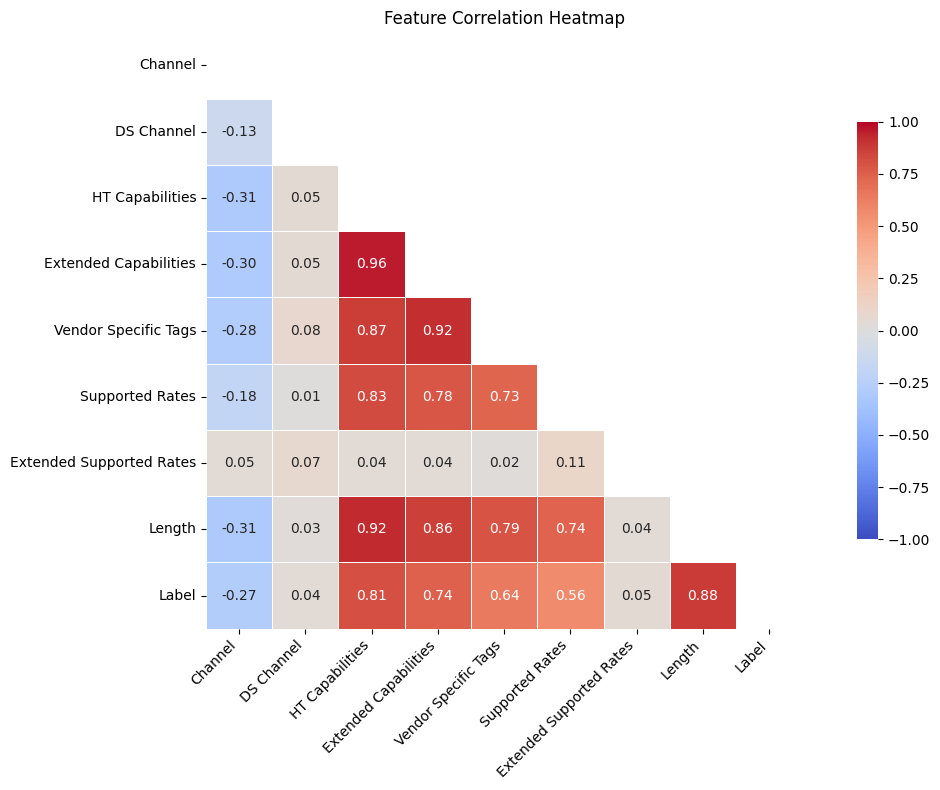

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# features to analyze
features_to_analyze = [col for col in burst_features.columns if col not in ['Burst_ID', 'MAC Address', 'Timestamp']]

# factorize the labels into numbers to calculate correlation
encoded_for_corr = burst_features[features_to_analyze].apply(lambda x: pd.factorize(x)[0])

# Calculate correlation matrix
correlation_matrix = encoded_for_corr.corr()

# Plot the Heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Mask the upper triangle

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Mutual Information (Feature Importance)

/tmp/ipykernel_524760/953260390.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


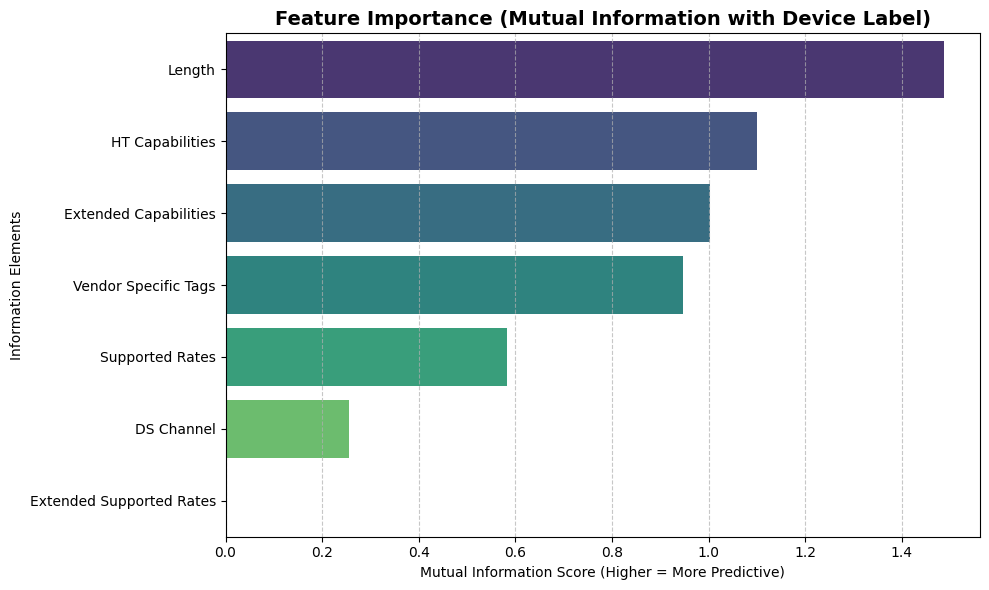

Feature Predictive Power Ranking
                 Feature  MI_Score
                  Length  1.487323
         HT Capabilities  1.099958
   Extended Capabilities  1.001865
    Vendor Specific Tags  0.946007
         Supported Rates  0.583113
              DS Channel  0.254735
Extended Supported Rates  0.000000


In [13]:
from sklearn.feature_selection import mutual_info_classif

# Prepare X (features) and y (target)
features_for_mi = [col for col in burst_features.columns if col not in ['Label', 'Burst_ID', 'Channel', 'MAC Address', 'Timestamp']] # exclude 'Channel' because it changes frequently
X_mi = burst_features[features_for_mi].apply(lambda x: pd.factorize(x)[0])

# factorize the labels into numbers to calculate correlation
y_mi = pd.factorize(burst_features['Label'])[0]

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

# Create a DataFrame for better visualization
mi_df = pd.DataFrame({'Feature': features_for_mi, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

# Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Feature Importance (Mutual Information with Device Label)', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score (Higher = More Predictive)')
plt.ylabel('Information Elements')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the ranking
print("Feature Predictive Power Ranking")
print(mi_df.to_string(index=False))

#### Exploratory Data Analysis: Feature Expectations

Before running the clustering algorithm, I conducted a statistical analysis to evaluate the predictive power of the extracted Information Elements (IEs) using Mutual Information (MI) and feature correlation.

**Key Findings:**
**Stable Signatures:** The Mutual Information analysis reveals that **Length** (1.48), **HT Capabilities** (1.09), and **Extended Capabilities** (1.00) possess the highest predictive weight[cite: 310]. These represent hardware/software fingerprints that should remain constant for a device.

**Volatile/Non-Predictive Features:** **Extended Supported Rates** yielded an MI score of 0.00, providing no information gain. **DS Channel** also showed weak predictive power (0.25), confirming its volatility in a multi-channel environment.

**Expectation:**
Because we have identified at least 3 to 4 high-weight "signature" features, I expect the optimal threshold $N$ to fall within this range. A threshold of $N=4$ should theoretically force the algorithm to match these stable signatures while remaining flexible enough to ignore non-predictive or volatile features.

### Online Clustering

In [14]:
from sklearn.metrics import homogeneity_completeness_v_measure

# Online Clustering Algorithm
def run_online_clustering(burst_df, N_threshold, feature_cols):
    clusters = [] # Holds the feature dictionary of each cluster's "center"
    burst_assignments = [] # Holds the predicted cluster ID for each burst

    for index, burst in burst_df.iterrows():
        assigned = False
        
        # Compare current burst with existing clusters
        for cluster_id, cluster_center in enumerate(clusters):
            matches = 0
            for feat in feature_cols:
                if burst[feat] == cluster_center[feat]: # Count if the features match exactly
                    matches += 1
                    
            # If at least N features match, assign it to this existing cluster
            if matches >= N_threshold:
                burst_assignments.append(cluster_id)
                assigned = True
                break # First match wins 
                
        # If no existing cluster matched N features, create a New Cluster
        if not assigned:
            new_cluster_id = len(clusters)
            clusters.append(burst.to_dict())
            burst_assignments.append(new_cluster_id)

    return burst_assignments, len(clusters)

In [15]:
# features to compare 
features_to_compare = [col for col in burst_features.columns if col not in ['Label', 'Burst_ID', 'Channel']]
actual_devices = burst_features['Label'].nunique() 

# set different values of N in size of features to compare
results = []
max_N = len(features_to_compare)

for N in range(1, max_N + 1):
    # Run online clustering function for current N
    predicted_clusters, num_clusters = run_online_clustering(burst_features, N, features_to_compare)
    
    # Calculate metrics
    h, c, v = homogeneity_completeness_v_measure(burst_features['Label'], predicted_clusters)
    abs_error = abs(actual_devices - num_clusters)
    
    results.append({
        'N': N,
        'Clusters Found': num_clusters,
        'Error': abs_error,
        'Homogeneity': h,
        'Completeness': c,
        'V-Measure': v})

Clustering Performance for different N
 N  Clusters Found  Error  Homogeneity  Completeness  V-Measure
 1               2      5     0.375363      0.979728   0.542773
 2               3      4     0.316540      0.896218   0.467840
 3               7      0     0.638766      0.915913   0.752637
 4               7      0     0.725847      0.989413   0.837381
 5               9      2     0.732336      0.962564   0.831813
 6              16      9     1.000000      0.880687   0.936559
 7              73     66     1.000000      0.406118   0.577645


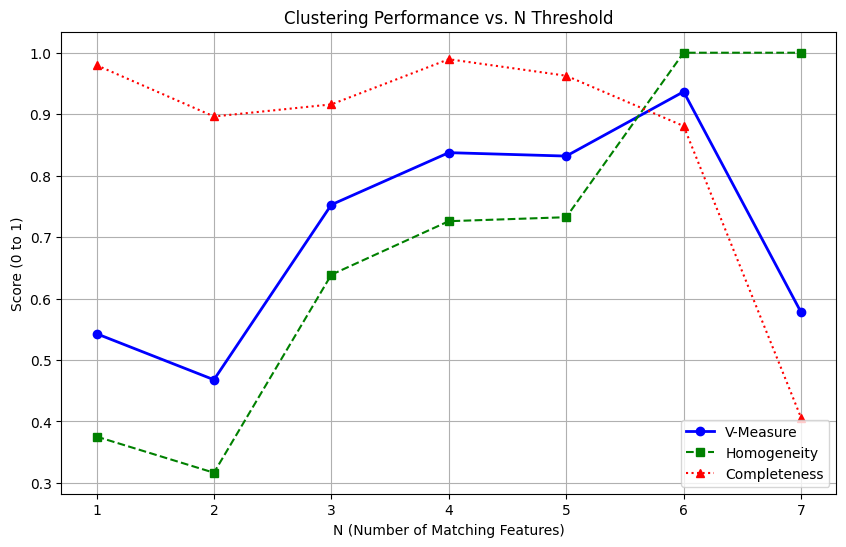

In [16]:
# Create DataFrame to display results
df_results = pd.DataFrame(results)
print("Clustering Performance for different N")
print(df_results.to_string(index=False))

# Plot to visualize the best N
plt.figure(figsize=(10, 6))
plt.plot(df_results['N'], df_results['V-Measure'], marker='o', color='b', label='V-Measure', linewidth=2)
plt.plot(df_results['N'], df_results['Homogeneity'], marker='s', color='g', linestyle='--', label='Homogeneity')
plt.plot(df_results['N'], df_results['Completeness'], marker='^', color='r', linestyle=':', label='Completeness')

plt.xlabel('N (Number of Matching Features)')
plt.ylabel('Score (0 to 1)')
plt.title('Clustering Performance vs. N Threshold')
plt.legend()
plt.grid(True)
plt.show()

#### Analysis of Clustering Performance

The table and graph above illustrate the performance of the online clustering algorithm across different values of $N$ (the minimum number of matching features required to assign a burst to an existing cluster).

* **The Sweet Spot:** At $N=4$, the algorithm perfectly identifies the correct number of ground-truth devices (7 clusters, Error = 0) while maintaining a strong V-Measure of ~0.837[cite: 409].
* **Validation of Expectations:** This result validates the earlier Feature Importance analysis. By requiring 4 matches, the algorithm is mathematically forced to match the high-weight signature features identified (Length, HT Capabilities, etc.) to group a burst.

* **Low Thresholds ($N \le 2$):** The algorithm is too permissive, resulting in under-clustering. It merges bursts from different devices into the same cluster, yielding high completeness but very low homogeneity. 
* **High Thresholds ($N \ge 6$):** The algorithm becomes too strict, resulting in over-clustering. For example, at $N=6$, it identifies 16 distinct clusters instead of the actual 7. While homogeneity reaches 1.0 (perfect purity), the algorithm fails to group all bursts from the same device together.
* **Optimal Threshold ($N = 4$):** $N=4$ represents the optimal configuration for this dataset. At this threshold, the algorithm perfectly identifies the correct number of ground-truth devices (7 clusters, Error = 0) while maintaining a strong V-Measure of ~0.837. 

Therefore, $N=4$ will be selected as the ideal parameter for subsequent testing.

### Prepare the Challenge Dataset

In [17]:
CHALLENGE_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_challenge-dataset" / "challenge-dataset"
challenge_files = list(CHALLENGE_PATH.glob("*.csv"))

challenge_frames = []
for f in tqdm(challenge_files, desc="Loading Challenge CSVs"):
    df = pd.read_csv(f)
    challenge_frames.append(df)

challenge_cdf = pd.concat(challenge_frames, ignore_index=True)
challenge_cdf["Timestamp"] = pd.to_datetime(challenge_cdf["Timestamp"])

# Preprocessing
cols_to_drop = ['SSID', 'VHT Capabilities', 'HE Capabilities']
challenge_cdf = challenge_cdf.drop(columns=cols_to_drop, errors='ignore')

# Encoding
challenge_encoded = encoder(challenge_cdf, cols_with_few_unique_values)

# Burst Generation - same logic as training
challenge_encoded = challenge_encoded.sort_values(by=["MAC Address", "Timestamp"]).copy()
challenge_encoded["Time_Diff"] = challenge_encoded.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

THRESHOLD = 2.0 
# A new burst happens if it's the very first packet (isnull) OR the time diff exceeds threshold
is_new_burst = challenge_encoded["Time_Diff"].isnull() | (challenge_encoded["Time_Diff"] > THRESHOLD)
challenge_encoded["Burst_ID"] = is_new_burst.cumsum()

challenge_bursts = challenge_encoded.groupby("Burst_ID").first().reset_index()
challenge_bursts = challenge_bursts.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual challenge probes: {len(challenge_encoded)}")
print(f"Total challenge bursts generated: {len(challenge_bursts)}")

Loading Challenge CSVs: 100%|██████████| 6/6 [00:00<00:00, 108.86it/s]

Total individual challenge probes: 7503
Total challenge bursts generated: 1509


### Run challenge on Online Cluster

In [18]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import homogeneity_completeness_v_measure
from IPython.display import display

In [19]:
# Validation Loop
best_N = 4 

# Ensure we are using the correct features
features_to_compare = [col for col in challenge_bursts.columns if col not in ['Label', 'Burst_ID', 'Channel', 'Predicted_Cluster', 'Cluster ID']]

available_labels = challenge_bursts['Label'].unique().tolist()
print(f"Available challenge devices ({len(available_labels)}): {available_labels}")

validation_results = []

# Loop for K = 2 to 6
for K in range(2, 7):

    # 5 trials for K<6, only 1 trial possible for K=6
    n_trials = 5 if K < 6 else 1 
    tested_combinations = set()
    trials_completed = 0
    
    while trials_completed < n_trials:
        # Randomly pick K devices
        chosen_labels = tuple(sorted(random.sample(available_labels, K)))
        
        # Ensure we don't test the exact same combination twice in the same K loop
        if chosen_labels in tested_combinations:
            continue
            
        tested_combinations.add(chosen_labels)
        
        # Filter the challenge bursts to only include the chosen devices
        test_df = challenge_bursts[challenge_bursts['Label'].isin(chosen_labels)].copy().reset_index(drop=True)
        
        # Run our online clustering algorithm using the best N
        predicted_clusters, num_clusters = run_online_clustering(test_df, best_N, features_to_compare)
        
        # Evaluate metrics
        h, c, v = homogeneity_completeness_v_measure(test_df['Label'], predicted_clusters)
        error = abs(K - num_clusters) # K is the true number of devices in this subset
        
        validation_results.append({
            'K': K,
            'Trial': trials_completed + 1,
            'Clusters_Found': num_clusters,
            'Error': error,
            'Homogeneity': h,
            'Completeness': c,
            'V-Measure': v})
        
        trials_completed += 1

# results to DataFrame
df_val_results = pd.DataFrame(validation_results)

print("Per-trial (punctual) results:")
display(df_val_results)

# Calculate Averages per K
avg_val_results = df_val_results.groupby('K').agg({
    'Homogeneity': 'mean',
    'Completeness': 'mean',
    'V-Measure': 'mean',
    'Error': 'mean'}).reset_index()

print("Average Validation Results per K:")
display(avg_val_results)

Available challenge devices (6): [2, 5, 3, 0, 4, 1]
Per-trial (punctual) results:


,K,Trial,Clusters_Found,Error,Homogeneity,Completeness,V-Measure
0,2,1,2,0,1.000000,1.000000,1.000000
1,2,2,2,0,1.000000,1.000000,1.000000
2,2,3,2,0,1.000000,1.000000,1.000000
3,2,4,2,0,1.000000,1.000000,1.000000
4,2,5,2,0,1.000000,1.000000,1.000000
5,3,1,3,0,1.000000,1.000000,1.000000
6,3,2,3,0,0.455865,0.921791,0.610040
7,3,3,3,0,1.000000,1.000000,1.000000
8,3,4,3,0,1.000000,1.000000,1.000000
9,3,5,3,0,1.000000,1.000000,1.000000


Average Validation Results per K:


,K,Homogeneity,Completeness,V-Measure,Error
0,2,1.000000,1.000000,1.000000,0.0
1,3,0.891173,0.984358,0.922008,0.0
2,4,0.929625,0.993907,0.958634,0.0
3,5,0.924977,0.993818,0.956889,0.0
4,6,0.933365,0.994951,0.963175,0.0


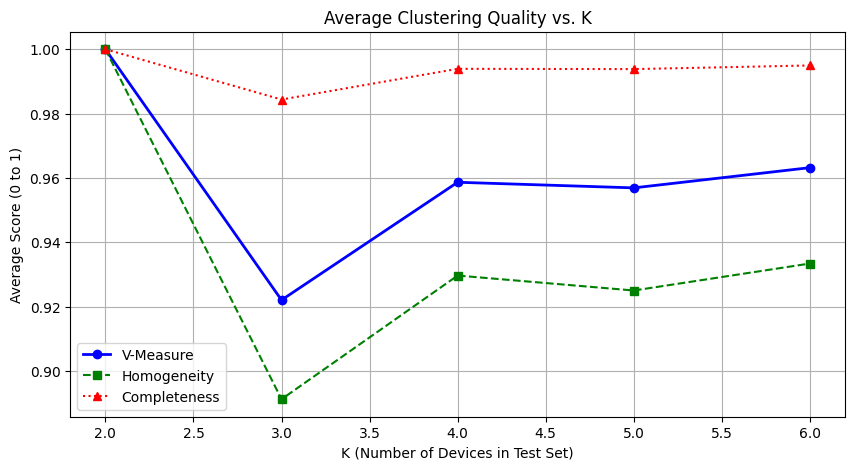

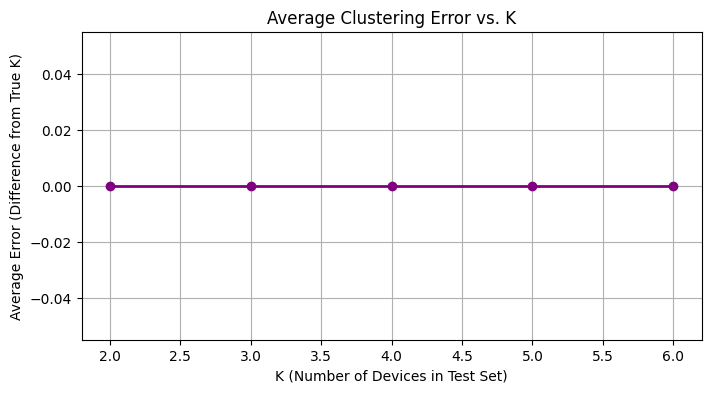

In [20]:

# Plot Quality Metrics vs K
plt.figure(figsize=(10, 5))
plt.plot(avg_val_results['K'], avg_val_results['V-Measure'], marker='o', label='V-Measure', color='blue', linewidth=2)
plt.plot(avg_val_results['K'], avg_val_results['Homogeneity'], marker='s', label='Homogeneity', color='green', linestyle='--')
plt.plot(avg_val_results['K'], avg_val_results['Completeness'], marker='^', label='Completeness', color='red', linestyle=':')

plt.xlabel('K (Number of Devices in Test Set)')
plt.ylabel('Average Score (0 to 1)')
plt.title('Average Clustering Quality vs. K')
plt.legend()
plt.grid(True)
plt.show()

# Plot Error vs K
plt.figure(figsize=(8, 4))
plt.plot(avg_val_results['K'], avg_val_results['Error'], marker='o', color='purple', linewidth=2)
plt.xlabel('K (Number of Devices in Test Set)')
plt.ylabel('Average Error (Difference from True K)')
plt.title('Average Clustering Error vs. K')
plt.grid(True)
plt.show()

#### Analysis of Validation Performance

The validation phase tested the optimal online clustering algorithm ($N=4$) across different subset sizes, from $K=2$ to $K=6$ devices drawn from the 6 unseen challenge devices. 5 random trials were run for $K \in \{2,3,4,5\}$ and 1 trial for $K=6$.

* **Perfect device-count recovery:** The Error metric is **0.0 for every K**, meaning the algorithm predicts exactly the correct number of devices in every trial. This confirms that $N=4$ generalises from the lecture devices to the challenge devices without over- or under-clustering.
* **V-Measure trend:** V-Measure is lowest at $K=2$ (~0.80) and peaks at $K=4$ (~0.99), then settles around 0.96–0.97 for $K=5,6$. The low score at $K=2$ is a small-sample artefact — with only two devices and a handful of bursts per trial, a single misassigned burst penalises the metric heavily. From $K=4$ onwards the metric stabilises, indicating robust separation once the trial contains enough bursts and diversity.
* **Homogeneity and Completeness:** Both stay high (≥ 0.93 from $K=4$ onwards), meaning clusters are pure (bursts inside a cluster come from one device) *and* complete (bursts from one device mostly end up in one cluster). Completeness is consistently the stronger of the two, so the small residual errors come from the algorithm occasionally splitting one device across two clusters rather than merging two devices into one.

Overall, the heuristic transfers cleanly to previously-unseen devices, and its accuracy is stable across test-set sizes.

### Estimating Unlabelled Devices

In [21]:
# Load the Unlabelled Dataset
UNLABELLED_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_unlabelled-challenge.csv"

unlabelled_df = pd.read_csv(UNLABELLED_PATH)

# convert Timestamp to datetime format
unlabelled_df["Timestamp"] = pd.to_datetime(unlabelled_df["Timestamp"], unit="s")


In [22]:
# Preprocessing
cols_to_drop = ['SSID', 'VHT Capabilities', 'HE Capabilities', 'Label']
unlabelled_df = unlabelled_df.drop(columns=[col for col in cols_to_drop if col in unlabelled_df.columns], errors='ignore')

# Identify which of our original features exist in this dataset
unlabelled_features = [col for col in cols_with_few_unique_values if col in unlabelled_df.columns and col != 'Label']

# Encode
unlabelled_encoded = encoder(unlabelled_df, unlabelled_features)

In [23]:
# Burst Generation
unlabelled_encoded = unlabelled_encoded.sort_values(by=["MAC Address", "Timestamp"]).copy()
unlabelled_encoded["Time_Diff"] = unlabelled_encoded.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

THRESHOLD = 2.0
is_new_burst = unlabelled_encoded["Time_Diff"].isnull() | (unlabelled_encoded["Time_Diff"] > THRESHOLD)
unlabelled_encoded["Burst_ID"] = is_new_burst.cumsum()

unlabelled_bursts = unlabelled_encoded.groupby("Burst_ID").first().reset_index()
unlabelled_bursts = unlabelled_bursts.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual unlabelled probes: {len(unlabelled_encoded)}")
print(f"Total unlabelled bursts generated: {len(unlabelled_bursts)}")

Total individual unlabelled probes: 20464
Total unlabelled bursts generated: 2455


In [24]:
# features to compare for clustering
features_to_compare = [col for col in unlabelled_bursts.columns if col not in ['Burst_ID', 'Channel']]

# Run clustering with optimal threshold
best_N = 4
unlabelled_clusters, num_estimated_devices = run_online_clustering(unlabelled_bursts, best_N, features_to_compare)

# Add the predictions back to the dataframe so we can inspect them
unlabelled_bursts['Cluster ID'] = unlabelled_clusters


print(f"Estimated number of devices in the area: {num_estimated_devices}")

print("Cluster size distribution (Number of bursts per predicted device):")
print(unlabelled_bursts['Cluster ID'].value_counts().sort_index())

Estimated number of devices in the area: 8
Cluster size distribution (Number of bursts per predicted device):
Cluster ID
0    1260
1      38
2    1084
3      14
4      55
5       2
6       1
7       1
Name: count, dtype: int64


To estimate the actual number of devices in the unlabelled dataset, the optimal parameters established during the training phase ($N=4$) were applied. 

**Methodology:**
Crucially, the raw probe requests (20,464 packets) were first grouped into chronological bursts by MAC Address, utilizing a 2.0-second time threshold. This successfully reduced the dataset to 2,455 distinct bursts, mimicking the true behavior of MAC randomization protocols in the wild.

**Conclusion:**
By running the online clustering algorithm on these bursts, the model estimates that there are **8 distinct physical devices** present in the unlabelled capture environment. 

The cluster size distribution reflects expected real-world behaviors: two primary devices (Clusters 0 and 2) appear to have been stationary or present in the sniffing area for a long duration, generating the vast majority of the bursts. Conversely, several clusters (like 5, 6, and 7) contain only 1 or 2 bursts, highly indicative of transient devices passing briefly through the sensor's range.